# Simulation 5 — GP-GLLVM at scale via K-subsets (composite ZQE)

**Big, fully-correlated groups; fit in seconds by touching only a small random
K-subset of each group** (GP marginal theorem), never the within-group `G×G`.

Model: `B` groups × `G` obs on grid `t`; within a group **all `G` are GP-correlated**
through the latent; groups independent; Poisson. Data generated **once** with full
correlation (one `G×G` Cholesky). Fitting (`gp.py`, `fit_gp_zqe`): per step sample a
minibatch of groups and a **random K-subset** of their points — any subset is an
exact GP draw `N(0,K(t_subset))`, so every op is `K×K`. Kernel lives in the decoder
(`ε→z=L(ℓ)ε→η`, so `ℓ` is learned by backprop); encoder = no-grad imputation.
Per-step cost `O(batch·K·p + K³)` — **independent of `G` and `B`**. `K` is a tunable
knob. (Vecchia/composite-likelihood block idea; novelty = likelihood-free for
non-Gaussian GLLVMs.)

In [1]:
%load_ext autoreload
%autoreload 2
import os, sys, time, numpy as np, torch, matplotlib.pyplot as plt, pandas as pd
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")) if "__file__" in globals() else ".")
if not os.path.exists("gp.py"): sys.path.insert(0, "simulations/simulation_5")
from gp import GPGLLVM, fit_gp_zqe, rbf_kernel
from gllvm.autofit import procrustes_error
torch.set_default_dtype(torch.float64)
plt.rcParams.update({"figure.dpi": 110})
DEV = "cuda" if torch.cuda.is_available() else "cpu"
Q, P, KVAR, ELL0 = 2, 30, 1.0, 2.0
print("device:", DEV, "| q:", Q, "| p:", P, "| true lengthscale:", ELL0)

device: cuda | q: 2 | p: 30 | true lengthscale: 2.0


## 1 · Big fully-correlated groups, fit on K=15 subsets — recovery + **flat fit time in G**

In [2]:
B, KSUB = 2000, 15
rows = []
for G in [50, 200, 1000]:
    t = torch.arange(G) * 0.1
    gp = GPGLLVM(Q, P, lengthscale=ELL0, kernel_var=KVAR, wz_scale=0.7, seed=0, device=DEV)
    W0 = gp.wz.cpu().clone()
    Yd = gp.sample_groups(t, B=B, seed=1)                     # B groups x G, full GP corr
    r = fit_gp_zqe(Yd, t, Q, subset_K=KSUB, kernel_var=KVAR, lengthscale_init=1.0,
                   steps=800, batch=256, true_W=W0, device=DEV)
    rows.append(dict(G=G, n=B*G, est_ell=round(r["lengthscale"],3),
                     W_procrustes=round(procrustes_error(W0, r["W"]),3),
                     fit_sec=round(r["time_sec"],1)))
    print(rows[-1], flush=True)
gtab = pd.DataFrame(rows); display(gtab)

{'G': 50, 'n': 100000, 'est_ell': 1.873, 'W_procrustes': 0.047, 'fit_sec': 3.7}


{'G': 200, 'n': 400000, 'est_ell': 1.96, 'W_procrustes': 0.015, 'fit_sec': 3.6}


{'G': 1000, 'n': 2000000, 'est_ell': 2.028, 'W_procrustes': 0.019, 'fit_sec': 3.5}


,G,n,est_ell,W_procrustes,fit_sec
0,50,100000,1.873,0.047,3.7
1,200,400000,1.960,0.015,3.6
2,1000,2000000,2.028,0.019,3.5


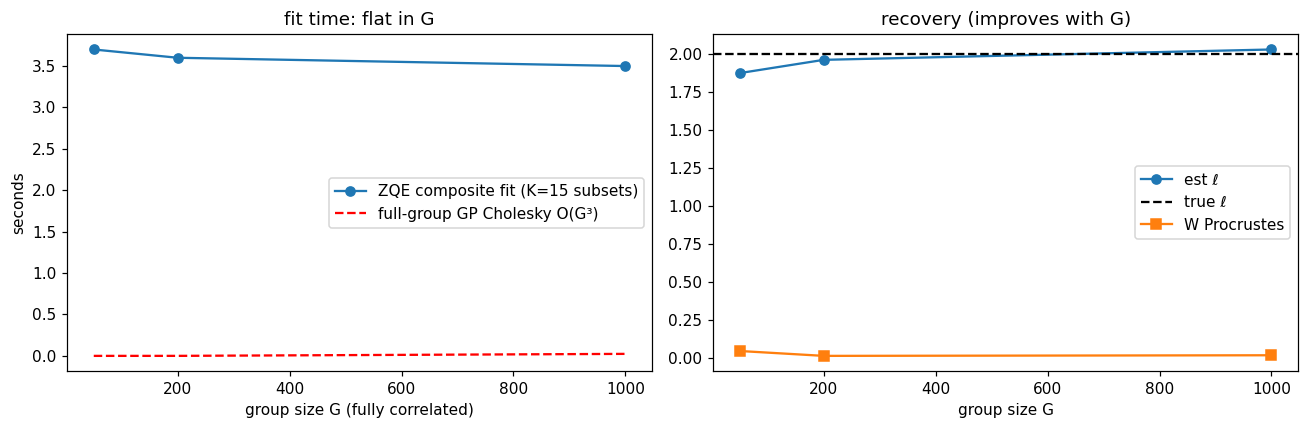

In [3]:
# fit time flat in G vs the O(G^3) full-group GP Cholesky wall
def chol_sec(G):
    A = rbf_kernel(torch.arange(G)*0.1, ELL0, KVAR).to(DEV)
    if DEV=="cuda": torch.cuda.synchronize()
    t0=time.time(); torch.linalg.cholesky(A)
    if DEV=="cuda": torch.cuda.synchronize();
    return time.time()-t0
Gs = np.array(gtab["G"]); c = np.mean([chol_sec(G)/G**3 for G in [200,500,1000]])
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(Gs, gtab["fit_sec"], "o-", label="ZQE composite fit (K=15 subsets)")
ax[0].plot(Gs, c*Gs**3, "r--", label="full-group GP Cholesky O(G³)")
ax[0].set_xlabel("group size G (fully correlated)"); ax[0].set_ylabel("seconds")
ax[0].set_title("fit time: flat in G"); ax[0].legend()
ax[1].plot(Gs, gtab["est_ell"], "o-", label="est ℓ"); ax[1].axhline(ELL0, color="k", ls="--", label="true ℓ")
ax[1].plot(Gs, gtab["W_procrustes"], "s-", label="W Procrustes")
ax[1].set_xlabel("group size G"); ax[1].set_title("recovery (improves with G)"); ax[1].legend()
plt.tight_layout(); plt.show()

## 2 · The K-subset knob (cost vs accuracy), at fixed G=200

In [4]:
t = torch.arange(200)*0.1
gp = GPGLLVM(Q, P, lengthscale=ELL0, kernel_var=KVAR, wz_scale=0.7, seed=0, device=DEV)
W0 = gp.wz.cpu().clone(); Yd = gp.sample_groups(t, B=2000, seed=1)
rk = []
for K in [5, 15, 40]:
    r = fit_gp_zqe(Yd, t, Q, subset_K=K, kernel_var=KVAR, lengthscale_init=1.0,
                   steps=800, batch=256, true_W=W0, device=DEV)
    rk.append(dict(K=K, est_ell=round(r["lengthscale"],3),
                   W_procrustes=round(procrustes_error(W0,r["W"]),3), fit_sec=round(r["time_sec"],1)))
display(pd.DataFrame(rk))

,K,est_ell,W_procrustes,fit_sec
0,5,1.928,0.030,2.5
1,15,1.960,0.015,3.1
2,40,1.939,0.023,4.0


## 3 · Scaling in the number of groups B (at G=200, K=15)

In [5]:
rb = []
for B in [1000, 5000, 20000]:
    t = torch.arange(200)*0.1
    gp = GPGLLVM(Q, P, lengthscale=ELL0, kernel_var=KVAR, wz_scale=0.7, seed=0, device=DEV)
    W0 = gp.wz.cpu().clone(); Yd = gp.sample_groups(t, B=B, seed=1)
    r = fit_gp_zqe(Yd, t, Q, subset_K=15, kernel_var=KVAR, lengthscale_init=1.0,
                   steps=800, batch=256, true_W=W0, device=DEV)
    rb.append(dict(B=B, n=B*200, est_ell=round(r["lengthscale"],3),
                   W_procrustes=round(procrustes_error(W0,r["W"]),3), fit_sec=round(r["time_sec"],1)))
    print(rb[-1], flush=True)
display(pd.DataFrame(rb))

{'B': 1000, 'n': 200000, 'est_ell': 1.972, 'W_procrustes': 0.024, 'fit_sec': 3.4}


{'B': 5000, 'n': 1000000, 'est_ell': 1.946, 'W_procrustes': 0.023, 'fit_sec': 3.3}


{'B': 20000, 'n': 4000000, 'est_ell': 1.972, 'W_procrustes': 0.019, 'fit_sec': 3.3}


,B,n,est_ell,W_procrustes,fit_sec
0,1000,200000,1.972,0.024,3.4
1,5000,1000000,1.946,0.023,3.3
2,20000,4000000,1.972,0.019,3.3


## 4 · Lengthscale recovery across true ℓ (same wrong init)

In [6]:
rl = []
t = torch.arange(200)*0.1
for ell0 in [1.0, 2.0, 3.0]:
    gp = GPGLLVM(Q, P, lengthscale=ell0, kernel_var=KVAR, wz_scale=0.7, seed=0, device=DEV)
    W0 = gp.wz.cpu().clone(); Yd = gp.sample_groups(t, B=2000, seed=1)
    r = fit_gp_zqe(Yd, t, Q, subset_K=15, kernel_var=KVAR, lengthscale_init=1.5,
                   steps=800, batch=256, device=DEV)
    rl.append(dict(true_ell=ell0, est_ell=round(r["lengthscale"],3),
                   W_procrustes=round(procrustes_error(W0,r["W"]),3)))
display(pd.DataFrame(rl))

,true_ell,est_ell,W_procrustes
0,1.0,0.997,0.020
1,2.0,1.960,0.015
2,3.0,3.029,0.015


## Takeaway

Groups of up to **G=1000 fully-correlated** observations (n up to ~2M) are fit in
~3.6 s, recovering the GP **lengthscale and loadings** — with **fit time independent
of G** because only random **K-subsets** are ever used (GP marginal theorem; `K`
tunable). The full-group GP likelihood is `O(G³)` and non-Gaussian-intractable, and
`gllvm` has no GP latent. This is the "fit GP-GLLVMs where likelihood methods can't"
result, and it generalizes directly to larger `q` and other response families.